## API Performance Monitoring Analysis

Project Overview

This project analyzes simulated API log data to monitor system performance and usage patterns.
The objective is to identify traffic trends, detect slow endpoints, measure response latency, and evaluate API reliability.

Through exploratory data analysis and visualization, the project examines key metrics such as:

- Total API request volume
- Average API response time
- Error rate across requests
- Most frequently used API endpoints
- Performance comparison between endpoints
- Time-based traffic patterns

The insights derived from this analysis help highlight potential performance bottlenecks and support better monitoring of backend API systems.

In [ ]:
import pandas as pd
import numpy as np
from faker import Faker
import random

fake = Faker()

rows = 8000

endpoints = ["/login", "/register", "/products", "/orders", "/payment", "/search", "/profile"]
methods = ["GET", "POST", "PUT", "DELETE"]
regions = ["US-East", "Europe", "Asia"]

data = {
    "timestamp": [fake.date_time_this_year() for _ in range(rows)],
    "endpoint": [random.choice(endpoints) for _ in range(rows)],
    "method": [random.choice(methods) for _ in range(rows)],
    "response_time_ms": np.random.randint(50, 1200, rows),
    "status_code": np.random.choice([200, 200, 200, 200, 404, 500], rows),
    "server_region": [random.choice(regions) for _ in range(rows)]
}

df = pd.DataFrame(data)
df.to_csv("api_logs_dataset.csv", index=False)

print("Dataset created successfully!")

Dataset created successfully!


## Load Dataset
In this section we load the API log dataset for analysis.

In [1]:
import pandas as pd
df = pd.read_csv("api_logs_dataset.csv")
df.head(100)

,timestamp,endpoint,method,response_time_ms,status_code,server_region
0,2026-03-03 08:02:55,/profile,POST,1063,500,US-East
1,2026-01-22 02:35:14,/login,PUT,128,200,Asia
2,2026-03-02 03:20:58,/register,DELETE,1034,404,Asia
3,2026-01-14 12:50:52,/register,GET,507,500,US-East
4,2026-02-27 06:47:33,/login,GET,1046,200,US-East
...,...,...,...,...,...,...
95,2026-02-25 01:57:38,/search,POST,249,200,US-East
96,2026-03-03 03:01:05,/products,DELETE,1132,200,US-East
97,2026-03-01 17:38:50,/register,PUT,67,500,Europe
98,2026-02-14 08:13:05,/profile,GET,1106,200,Asia


## Dataset Overview
Check dataset structure and data types.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   timestamp         8000 non-null   object
 1   endpoint          8000 non-null   object
 2   method            8000 non-null   object
 3   response_time_ms  8000 non-null   int64 
 4   status_code       8000 non-null   int64 
 5   server_region     8000 non-null   object
dtypes: int64(2), object(4)
memory usage: 375.1+ KB


In [11]:
df.shape

(8000, 6)

## KPI Calculation
This section calculates important metrices such as total API requests, average respons time, error rate, and success rate

In [13]:
#KPI 1: Total API Requets
total_requests = df.shape[0]
print ("Total API Requests:",total_requests)

Total API Requests: 8000


In [16]:
#KPI 2: Average Response Time
avg_response_time = df["response_time_ms"].mean()
print("Average Response Time:", avg_response_time)

Average Response Time: 623.199125


In [20]:
#KPI 3: Error Rate
error_rate = (df["status_code"]!=200).mean()*100
print("Error Rate:", error_rate, "%")

Error Rate: 33.725 %


In [21]:
#KPI 4: Success Rate
success_rate = (df["status_code"]==200).mean()*100
print("Sucess Rate:" , success_rate, "%")

Sucess Rate: 66.27499999999999 %


## API Enpoint Analysis
Identify the most frequently used API enpoints


In [23]:
#Count API requests per endpoint
df["endpoint"].value_counts()

endpoint
/register    1179
/products    1157
/orders      1144
/search      1141
/profile     1134
/login       1132
/payment     1113
Name: count, dtype: int64

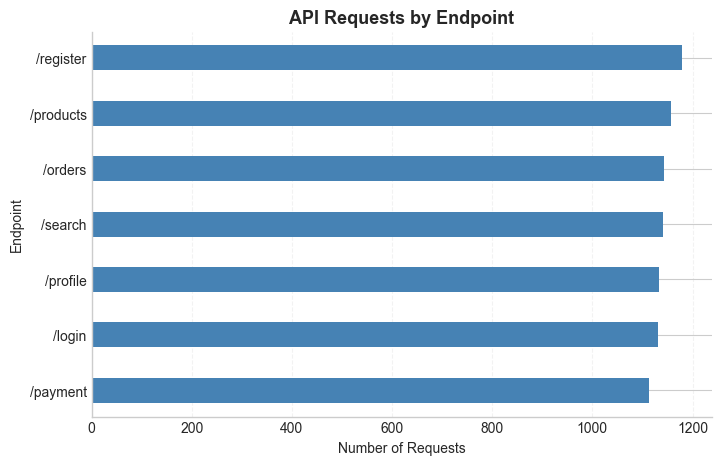

In [37]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

endpoint_counts = df["endpoint"].value_counts().sort_values()

plt.figure(figsize=(8,5))
ax = endpoint_counts.plot(kind="barh", color="steelblue", width=0.45)

plt.title("API Requests by Endpoint", fontsize=13 , weight ="bold")
plt.xlabel("Number of Requests")
plt.ylabel("Endpoint")

plt.grid(axis="x", linestyle="--", alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()


-- Endpoint Insight

The analysis shows that API requests are distributed across several endpoints, with /register receiving the highest number of requests.
This indicates that user registration activity is the most frequent operation in the system. Other endpoints such as /products and /orders also receive substantial traffic, suggesting consistent interaction with product and order-related services.

## API Performance Analysis
Identify which API are slow

### Response Time Distribution

This analysis examines how API response times are distributed across all requests. 
Understanding the distribution of response times helps identify typical performance levels and detect potential latency issues within the system.

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df["response_time_ms"],
    bins=30,
    color="plum",
    edgecolor="white",
    linewidth=0.7
)

plt.title("Distribution of API Response Time", fontsize=14, weight="bold")
plt.xlabel("Response Time (ms)")
plt.ylabel("Frequency")

plt.grid(axis="y", linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

<Figure size 800x500 with 0 Axes>

-- Response Time Insight

The response time distribution indicates that most API requests are processed within a moderate latency range.
This suggests that the system generally maintains stable performance. However, a small number of requests experience higher response times, which may represent temporary load spikes or slower backend operations.

### Performance Insight

The response time distribution shows that most API requests fall within a moderate latency range, indicating stable system performance. 
However, a smaller number of requests experience higher response times, which may represent slower endpoints or temporary system load.

In [39]:
#Average response time by endpoint
endpoint_performance = df.groupby("endpoint")["response_time_ms"].mean().sort_values()
endpoint_performance

endpoint
/search      604.861525
/register    610.939779
/payment     612.832884
/orders      623.314685
/login       626.649293
/products    637.599827
/profile     646.316578
Name: response_time_ms, dtype: float64

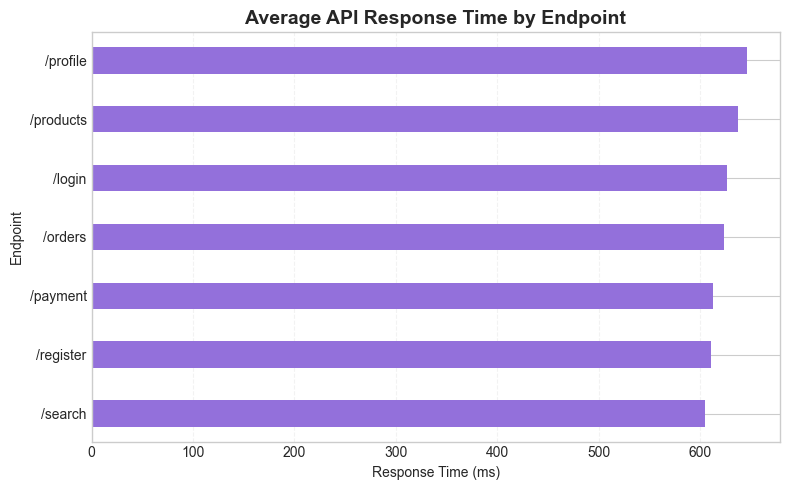

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

endpoint_performance.plot(kind="barh", color="mediumpurple", width=0.45)

plt.title("Average API Response Time by Endpoint", fontsize=14, weight="bold")
plt.xlabel("Response Time (ms)")
plt.ylabel("Endpoint")

plt.grid(axis="x", linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

-- Endpoint Performance Insight

The comparison of average response times across endpoints reveals variations in API performance.
The /profile endpoint shows the highest average response time, indicating that it may require further optimization. Monitoring these slower endpoints can help improve overall system responsiveness and user experience.

## Time- Based Traffic Analysis
Identify peak API usage times.

In [25]:
#Convert timestamp to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

#Extract Hour
df["hour"] = df["timestamp"].dt.hour

#Count requests per hour
df["hour"].value_counts().sort_index()

hour
0     354
1     306
2     314
3     332
4     303
5     334
6     354
7     316
8     342
9     331
10    330
11    337
12    314
13    340
14    357
15    348
16    324
17    346
18    298
19    348
20    348
21    362
22    327
23    335
Name: count, dtype: int64

In [27]:
peak_hour = df["hour"].value_counts().idxmax()
peak_requests = df["hour"].value_counts().max()

print("Peak traffic hour:", peak_hour)
print("Requests during peak hour:", peak_requests)

Peak traffic hour: 21
Requests during peak hour: 362


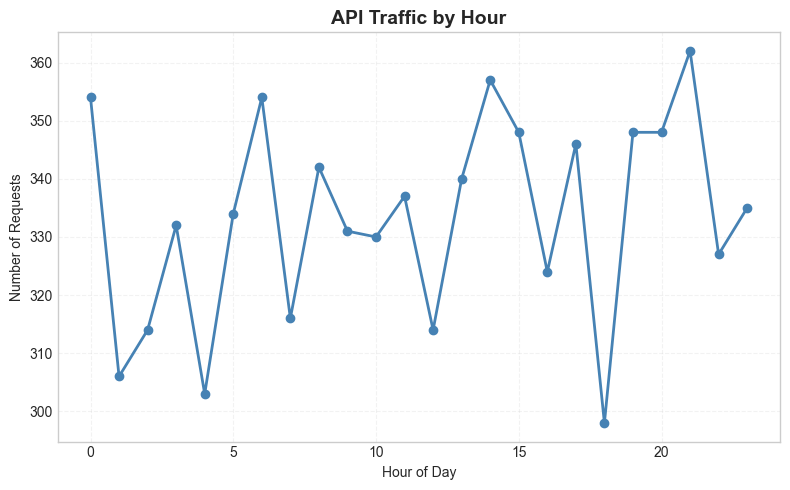

In [48]:
import matplotlib.pyplot as plt

hourly_traffic = df["hour"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.plot(hourly_traffic.index, hourly_traffic.values,
         marker="o", linewidth=2, color="steelblue")

plt.title("API Traffic by Hour", fontsize=14, weight="bold")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Requests")

plt.grid(True, linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

-- Traffic Insight

The hourly traffic analysis shows that API usage fluctuates throughout the day.
The system experiences peak activity around 21:00 (9 PM), indicating higher user engagement during late evening hours. In contrast, request volume decreases around 18:00 (6 PM), representing a period of lower system usage.

## Error Analysis
This section examines API requests that returned non-success status codes.
Analyzing errors helps identify endpoints that frequently fail and may require further monitoring or optimization.

Understanding error distribution across endpoints allows engineering teams to detect potential reliability issues and improve backend service stability.

In [55]:

error_rate = df.groupby("endpoint")["status_code"].apply(
    lambda x: (x != 200).mean() * 100
)

error_rate = error_rate.sort_values()

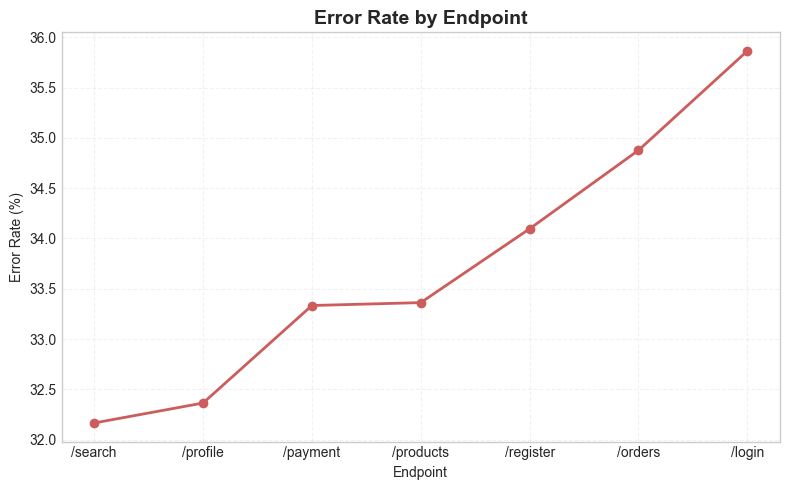

In [56]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(
    error_rate.index,
    error_rate.values,
    marker="o",
    linewidth=2,
    color="indianred"
)

plt.title("Error Rate by Endpoint", fontsize=14, weight="bold")
plt.xlabel("Endpoint")
plt.ylabel("Error Rate (%)")

plt.grid(True, linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

-- Error Analysis Insight

The error rate analysis highlights which API endpoints generate a higher percentage of failed requests.
Endpoints with elevated error rates may indicate unstable services or issues with request handling. Monitoring these endpoints can help developers identify and resolve potential reliability problems within the system.

## Status Code Distribution

This section analyzes the distribution of HTTP status codes returned by the API.
Status codes provide insight into request outcomes, including successful responses, client errors, and server errors.

Examining the distribution of these codes helps evaluate the overall reliability and stability of the API system.

In [57]:
status_counts = df["status_code"].value_counts().sort_index()
print(status_counts)

status_code
200    5302
404    1362
500    1336
Name: count, dtype: int64


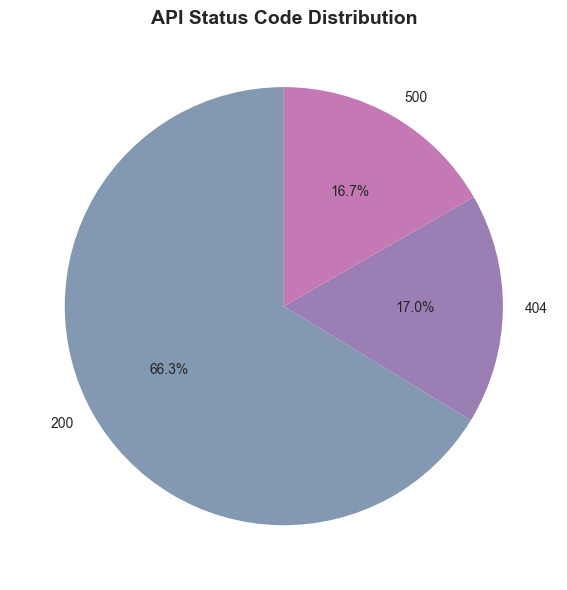

In [64]:
import matplotlib.pyplot as plt

# Count status codes
status_counts = df["status_code"].value_counts()

# Plot pie chart
plt.figure(figsize=(6,6))

plt.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct="%1.1f%%",
    colors=["#8399B2", "#9b7eb4", "#C479B4"],
    startangle=90
)

plt.title("API Status Code Distribution", fontsize=14, weight="bold")

plt.tight_layout( )
plt.show()

-- Status Code Insight

The distribution of HTTP status codes provides an overview of API reliability.
A majority of responses return successful status codes, indicating that most API requests are handled correctly. However, the presence of client and server error responses suggests areas where system monitoring and debugging may be necessary to maintain stable performance.

## Key Insights

- The dataset contains 8000 API requests, showing significant activity across multiple API endpoints.
- The /register endpoint receives the highest number of requests, indicating it is the most frequently used service in the system.
- The average API response time is approximately 623 ms, suggesting overall stable performance for most requests.
- The /profile endpoint has the highest average response time, which may indicate a potential performance bottleneck requiring optimization.
- API traffic varies throughout the day, with peak activity around 21:00 (9 PM) and the lowest activity occurring around 18:00 (6 PM).
- Error rate analysis shows that some endpoints experience higher failure rates, highlighting areas that may need further monitoring or debugging.
- The status code distribution indicates that most API requests are successful, while a smaller portion results in client or server errors.

## Conclusion

This project analyzed simulated API log data to evaluate system performance, endpoint usage, and traffic patterns. By examining key metrics such as request volume, response time, error rate, and hourly traffic distribution, the analysis provided valuable insights into how the API system operates.

The results highlight important patterns in API usage, identify endpoints with higher latency or error rates, and reveal peak traffic periods throughout the day. These insights can help engineering teams monitor system reliability, detect potential performance bottlenecks, and optimize backend services for improved efficiency and user experience.

Overall, the analysis demonstrates how data-driven monitoring can support better decision-making in managing and optimizing API-based systems.